In [1]:
import tensorflow as tf
import tensorflow_io as tfio
import tensorflow_addons as tfa
from tensorflow.keras.models import load_model

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2 
from itertools import combinations

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed
import face_recognition
import random
from scipy.interpolate import LinearNDInterpolator
from scipy import stats

import mediapipe as mp

from fid import get_frechet_inception_distance
import pandas as pd

2023-06-02 14:20:35.519318: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-02 14:20:35.573535: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow com

In [2]:
COHERENCE_LOSS = "l1"
MAIN_LOSS = "l1"
LANDMARKS_LOSS = None
LANDMARKS_COHERENCE_LOSS = "l1"

# Dimensions
r = 64
BATCH_SIZE = 100
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68


STEPS = 100000
STEPS = STEPS // BATCH_SIZE

LAMBDA1 = 1000
LAMBDA2 = 200
LAMBDA3 = 1000
LAMBDA4 = 200

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'

## Load the dataset

In [3]:
videos_path = list((DATA_PATH / VIDEOS_FOLDER).glob('**/*.npy'))

In [4]:
from mug import FrameDataGenerator, plot_normalized_sequence, get_generator_model, get_discriminator_model, l1_loss, euclidean_distance

In [5]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

tf.print(len(train_paths))
tf.print(len(test_paths))

722
310


2023-06-02 14:20:41.733340: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2023-06-02 14:20:41.733425: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: d1cd2a84beb7
2023-06-02 14:20:41.733448: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: d1cd2a84beb7
2023-06-02 14:20:41.733700: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2023-06-02 14:20:41.733758: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: 525.105.17


In [6]:
train_generator = FrameDataGenerator(train_paths, batch_size=BATCH_SIZE)
test_generator = FrameDataGenerator(test_paths, batch_size=BATCH_SIZE)

previous_frame, current_frame, next_frame = next(test_generator)
tf.print(previous_frame.shape)
tf.print(current_frame.shape)
tf.print(next_frame.shape)

(100, 64, 64, 3)
(100, 64, 64, 3)
(100, 64, 64, 3)


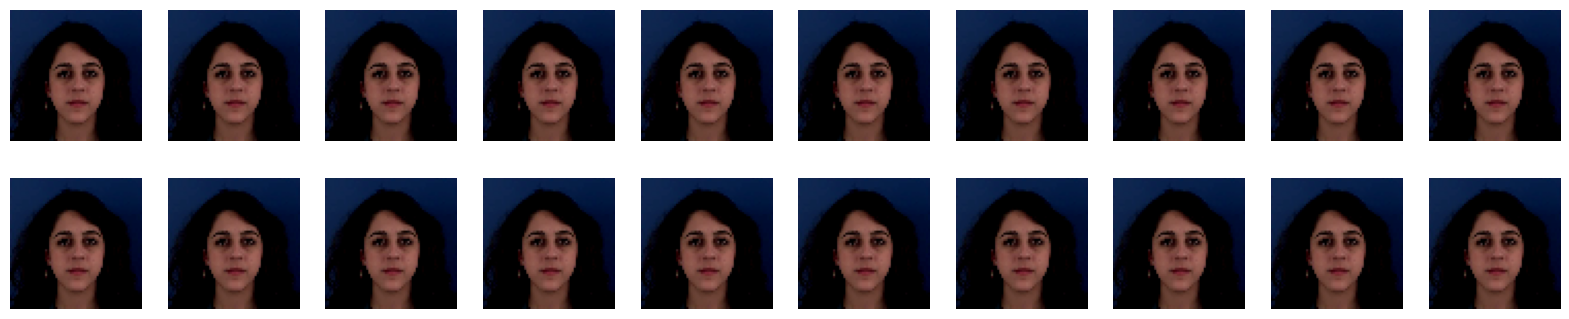

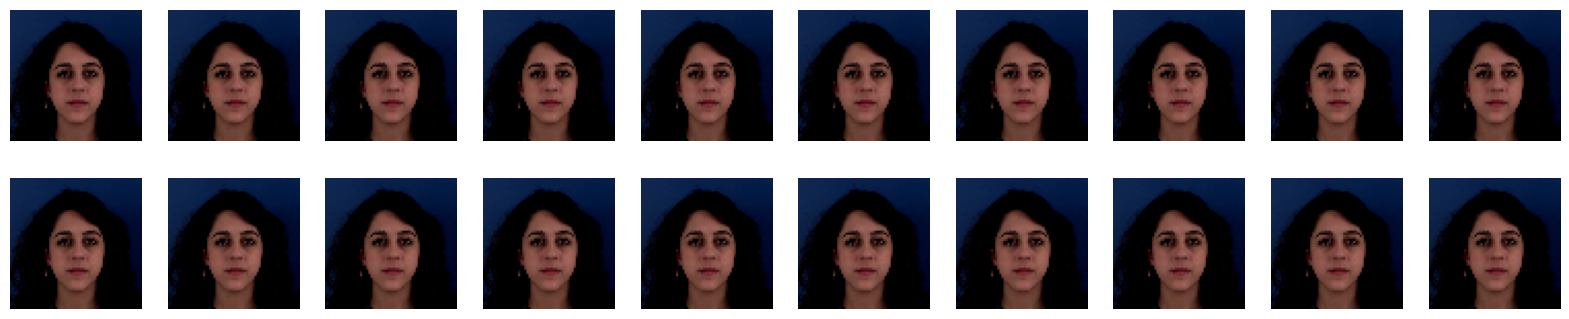

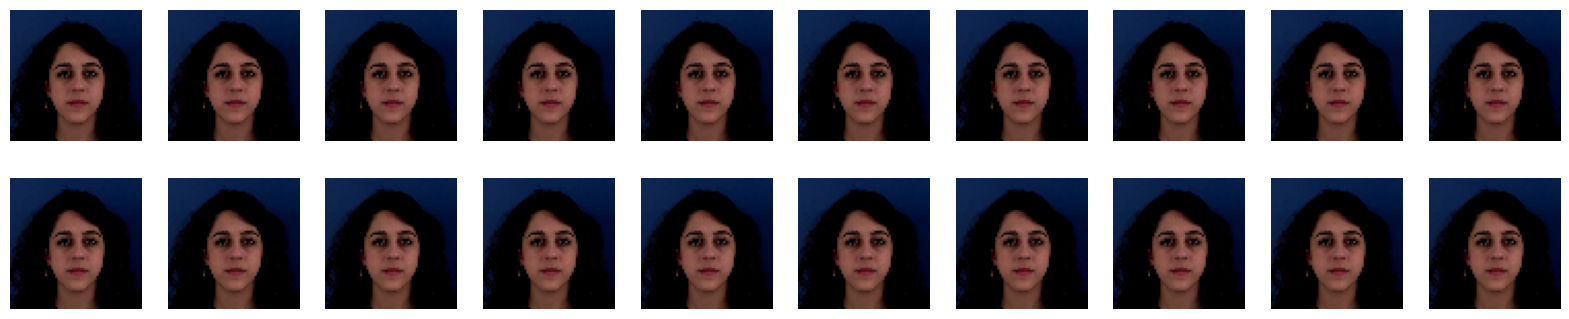

In [7]:
plot_normalized_sequence(previous_frame)
plot_normalized_sequence(current_frame)
plot_normalized_sequence(next_frame)

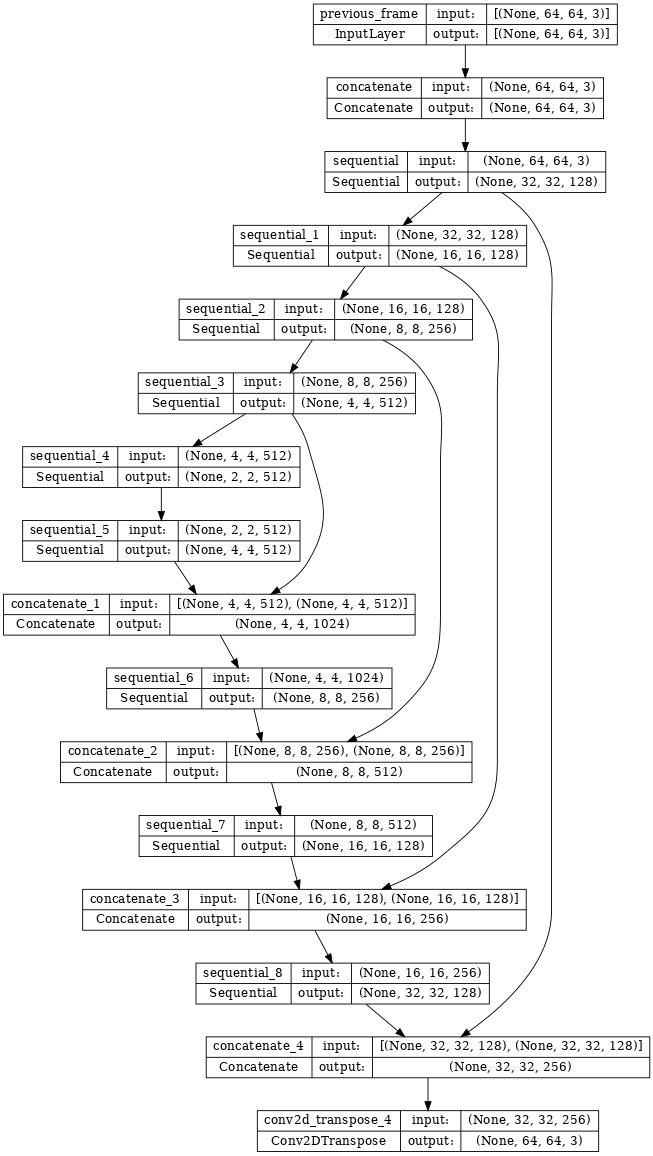

In [8]:
generator = get_generator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file='output/generator.png')

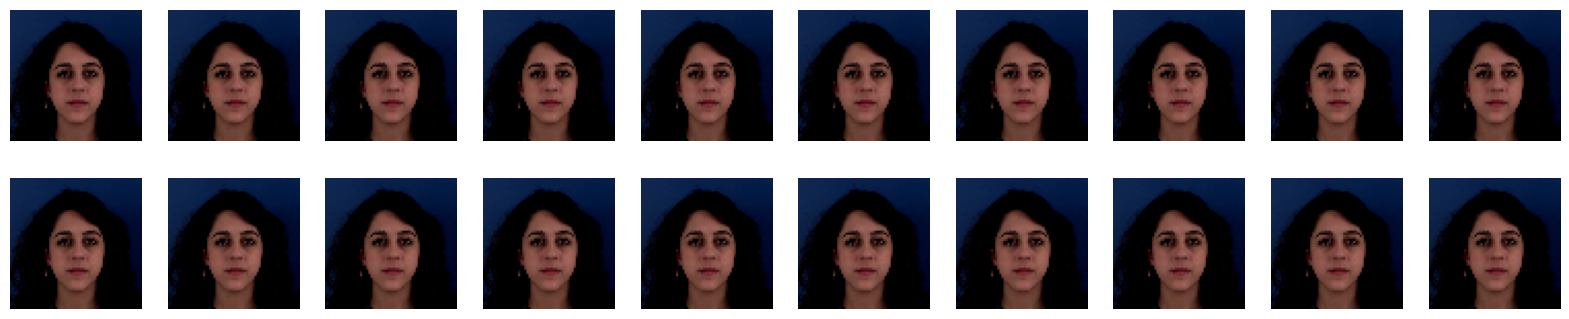

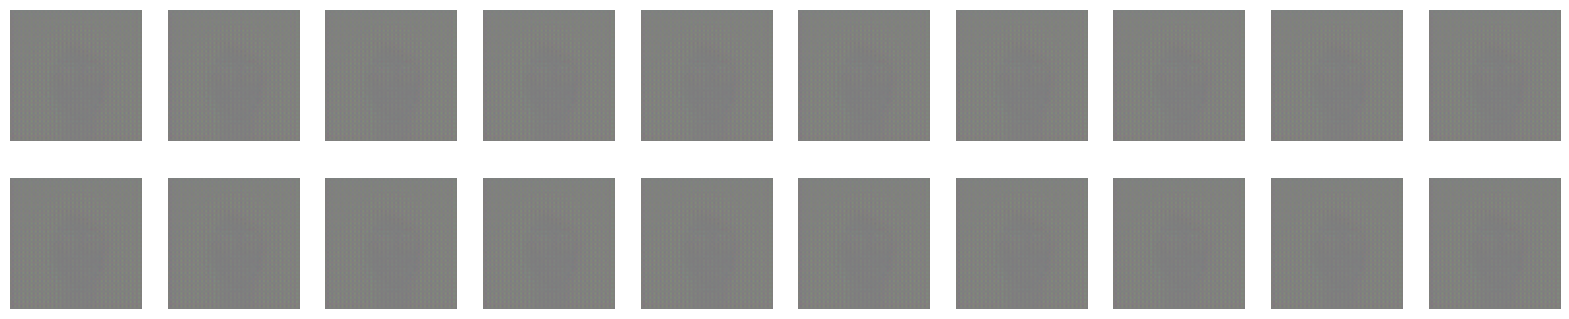

In [9]:
get_outputs =  generator(current_frame, training=False)

plot_normalized_sequence(current_frame)
plot_normalized_sequence(get_outputs)

## Comparing loss functions

In [10]:
GENERATOR_LOSS_FUNCTIONS = {
    'l1': l1_loss,
    'l2': euclidean_distance,
    # 'pairwise': pairwise_loss,
    # 'displacements': get_tensors_displacements,
    # 'perceptual': perceptual_loss,
    # 'test_landmarks': landmark_loss
}

landmarks_losses_functions = ['pairwise', 'displacements']

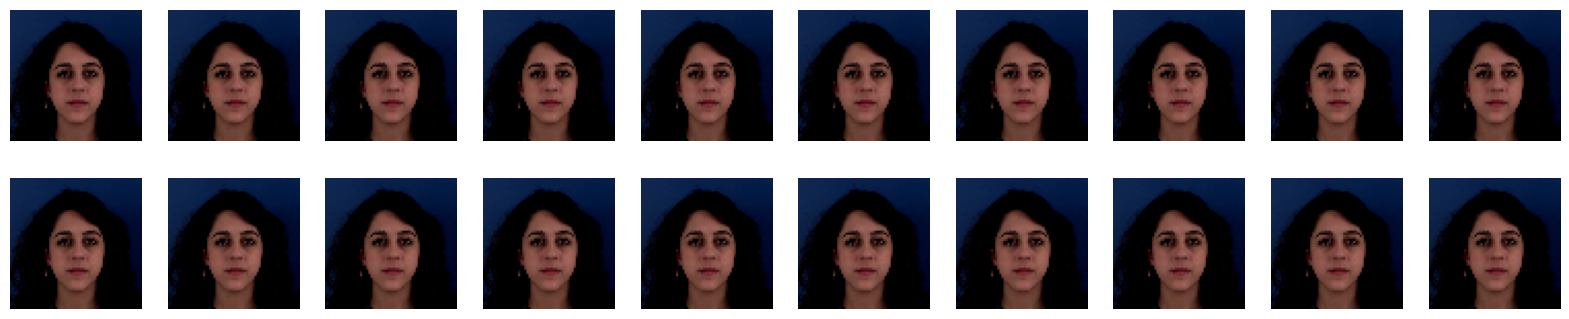

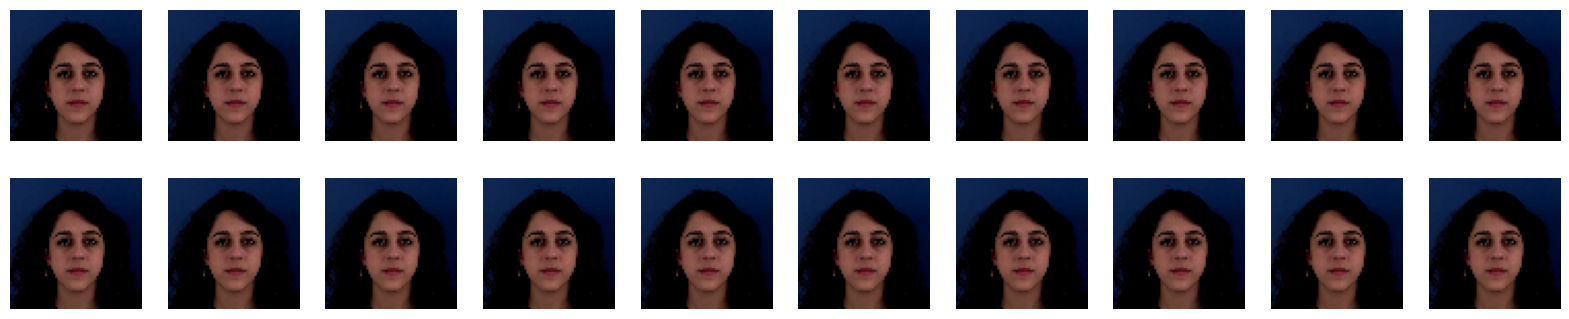

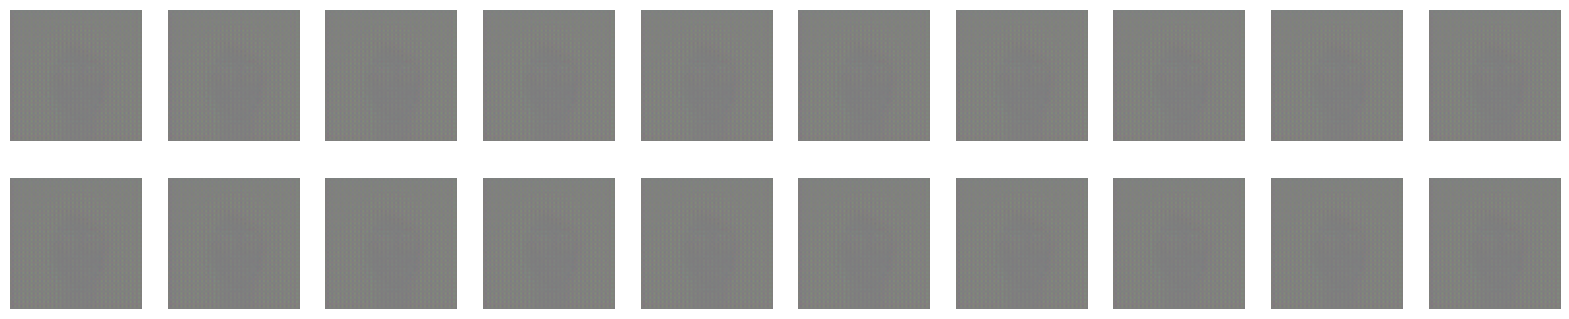

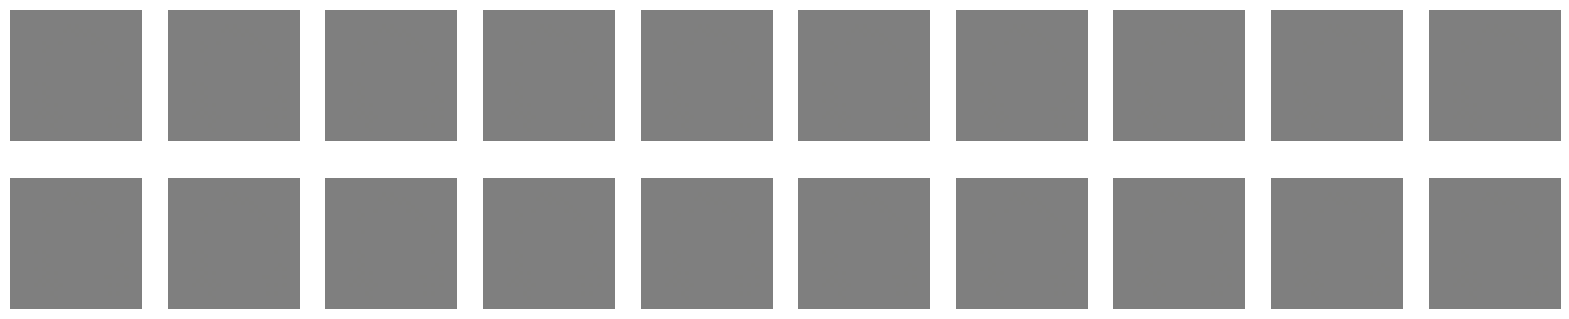

current_frame dtype('float64')
next_frame dtype('float64')
gen_output_sample tf.float32
gen_output_next_sample tf.float32


In [11]:
gen_output_sample = generator(current_frame, training=False)
gen_output_next_sample = generator(gen_output_sample, training=False)
plot_normalized_sequence(current_frame)
plot_normalized_sequence(next_frame)
plot_normalized_sequence(gen_output_sample)
plot_normalized_sequence(gen_output_next_sample)

# print types
tf.print("current_frame", current_frame.dtype)
tf.print("next_frame", next_frame.dtype)
tf.print("gen_output_sample", gen_output_sample.dtype)
tf.print("gen_output_next_sample", gen_output_next_sample.dtype)

In [12]:
from mug import mean_loss, coherence_mean_loss, coherence_mean_landmarks_loss, DlibLandmarksDetector

In [13]:
landmark_detector = DlibLandmarksDetector(batch_size=BATCH_SIZE, num_landmarks=N_LANDMARKS)

In [14]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    if loss_function not in landmarks_losses_functions:
        tf.print("================================", loss_function, "================================")
        loss_value = mean_loss(next_frame,gen_output_sample,GENERATOR_LOSS_FUNCTIONS[loss_function])
        tf.print(loss_value)

================================ l1 ================================


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


0.781858683
================================ l2 ================================
1.38261127


In [15]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    if loss_function not in landmarks_losses_functions:
        tf.print("================================", loss_function, "================================")
        loss_value = coherence_mean_loss(current_frame, next_frame, gen_output_sample, gen_output_next_sample, GENERATOR_LOSS_FUNCTIONS[loss_function])
        tf.print(loss_value)

================================ l1 ================================
1.68237305
================================ l2 ================================
10.6844


In [16]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    tf.print("================================", loss_function, "================================")
    print(current_frame.shape)
    print(next_frame.shape)
    print(gen_output_sample.shape)
    print(gen_output_next_sample.shape)
    
    current_frame_landmarks = landmark_detector.preprocess_and_detect_landmarks(current_frame)
    next_frame_landmarks = landmark_detector.preprocess_and_detect_landmarks(next_frame)
    gen_output_sample_landmarks = landmark_detector.preprocess_and_detect_landmarks(gen_output_sample)
    gen_output_next_sample_landmarks = landmark_detector.preprocess_and_detect_landmarks(gen_output_next_sample)
    loss_value = mean_loss(current_frame_landmarks, gen_output_sample_landmarks, GENERATOR_LOSS_FUNCTIONS[loss_function])
    tf.print(loss_value)

================================ l1 ================================
(100, 64, 64, 3)
(100, 64, 64, 3)
(100, 64, 64, 3)
(100, 64, 64, 3)
35.0310249
================================ l2 ================================
(100, 64, 64, 3)
(100, 64, 64, 3)
(100, 64, 64, 3)
(100, 64, 64, 3)
50.3099251


In [17]:
for loss_function in GENERATOR_LOSS_FUNCTIONS:
    tf.print("================================", loss_function, "================================")
    current_frame_landmarks = landmark_detector.preprocess_and_detect_landmarks(current_frame)
    next_frame_landmarks = landmark_detector.preprocess_and_detect_landmarks(next_frame)
    gen_output_sample_landmarks = landmark_detector.preprocess_and_detect_landmarks(gen_output_sample)
    gen_output_next_sample_landmarks = landmark_detector.preprocess_and_detect_landmarks(gen_output_next_sample)
    loss_value = coherence_mean_landmarks_loss(current_frame_landmarks[0], next_frame_landmarks[0], gen_output_sample_landmarks[0], gen_output_next_sample_landmarks[0], GENERATOR_LOSS_FUNCTIONS[loss_function])
    tf.print(loss_value)

================================ l1 ================================
0.130916819
================================ l2 ================================
0.215091154


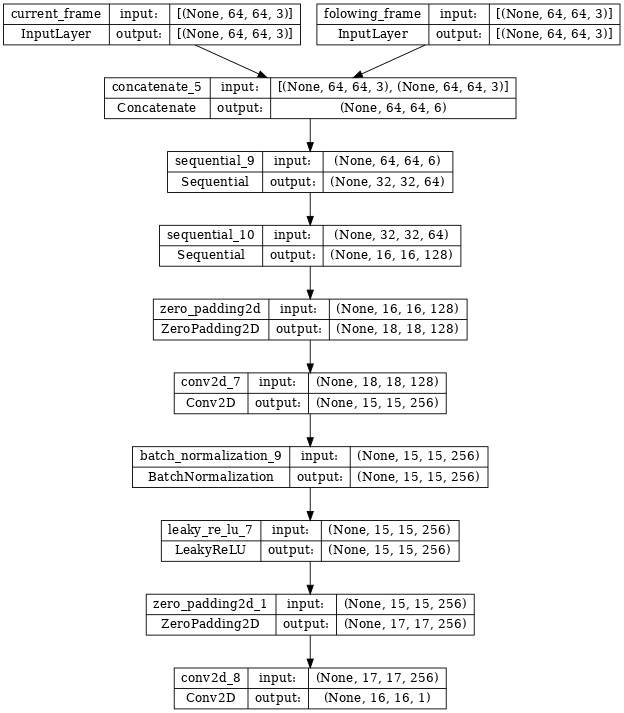

In [18]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file='output/discriminator.png')

Test the discriminator:

TensorShape([100, 16, 16, 1])


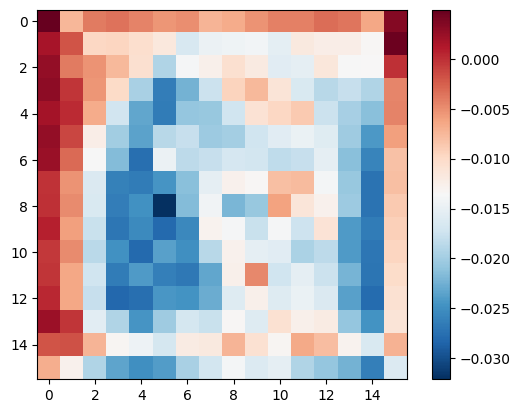

In [19]:
disc_out = discriminator([current_frame, gen_output_sample], training=False)
tf.print(disc_out.shape)
plt.imshow(disc_out[0, ..., -1], cmap='RdBu_r')
plt.colorbar()
plt.show()
plt.close()

In [20]:
from mug import GeneratorLoss, DiscriminatorLoss, pairwise_loss

In [21]:
generator_loss = GeneratorLoss(landmark_detector,
                l1_loss,
                lambda_main_loss=LAMBDA1,
                coherence_loss_function=l1_loss,
                lambda_coherence_loss=LAMBDA2,
                landmarks_loss_function=None,
                lambda_landmarks_loss=0,
                landmarks_coherence_loss_function=pairwise_loss,
                lambda_landmarks_coherence_loss=LAMBDA4)

In [22]:
gen_total_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss = generator_loss(
    disc_out, gen_output_sample, gen_output_next_sample, current_frame, next_frame
)
print(gen_total_loss)

tf.Tensor(1112.8727, shape=(), dtype=float32)


In [23]:
discriminator_loss = DiscriminatorLoss()

In [24]:
disc_real_output = discriminator([current_frame, next_frame], training=False)
disc_generated_output = discriminator([current_frame, gen_output_sample], training=False)
discriminator_loss(disc_real_output, disc_generated_output)

<tf.Tensor: shape=(), dtype=float32, numpy=1.3919187>

## Define the optimizers and a checkpoint-saver


In [25]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [26]:
id_string = ""
if MAIN_LOSS:
    id_string += f"{MAIN_LOSS}_{LAMBDA1}"
if COHERENCE_LOSS:
    id_string += f"_{COHERENCE_LOSS}_{LAMBDA2}"
if LANDMARKS_LOSS:
    id_string += f"_{LANDMARKS_LOSS}_{LAMBDA3}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_{LANDMARKS_COHERENCE_LOSS}_{LAMBDA4}"
id_string += f"_BATCH_SIZE_{BATCH_SIZE}"
id_string

'l1_1000_l1_200_l1_200_BATCH_SIZE_100'

In [27]:
BASE_DIR = APP_PATH / 'output'
checkpoint_dir = str(BASE_DIR /  id_string / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [28]:
from mug import generate_sequences

Input Sequence


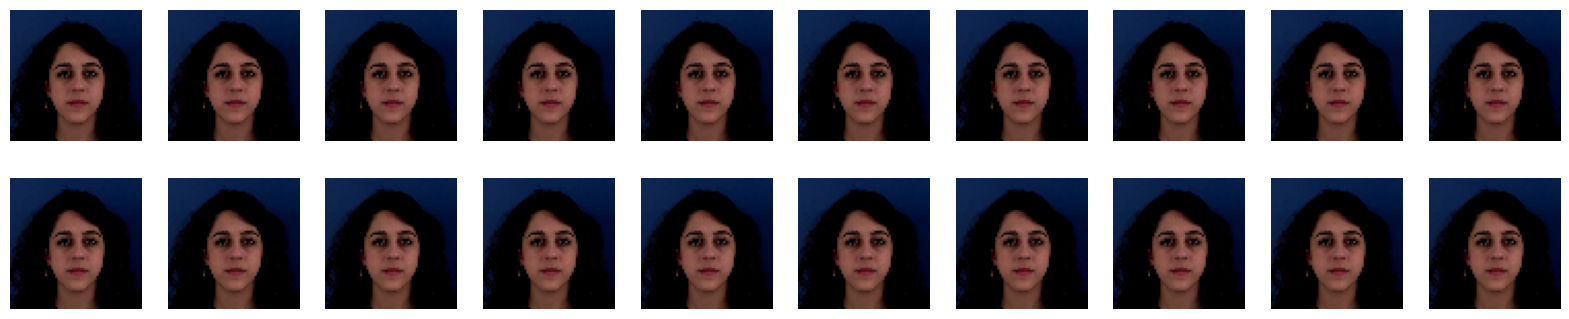

Ground Truth


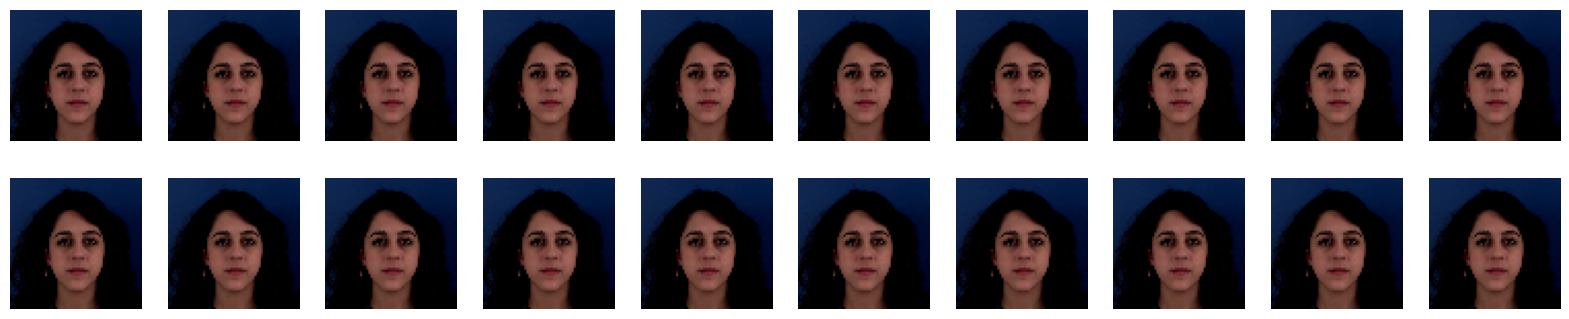

Predicted Sequence


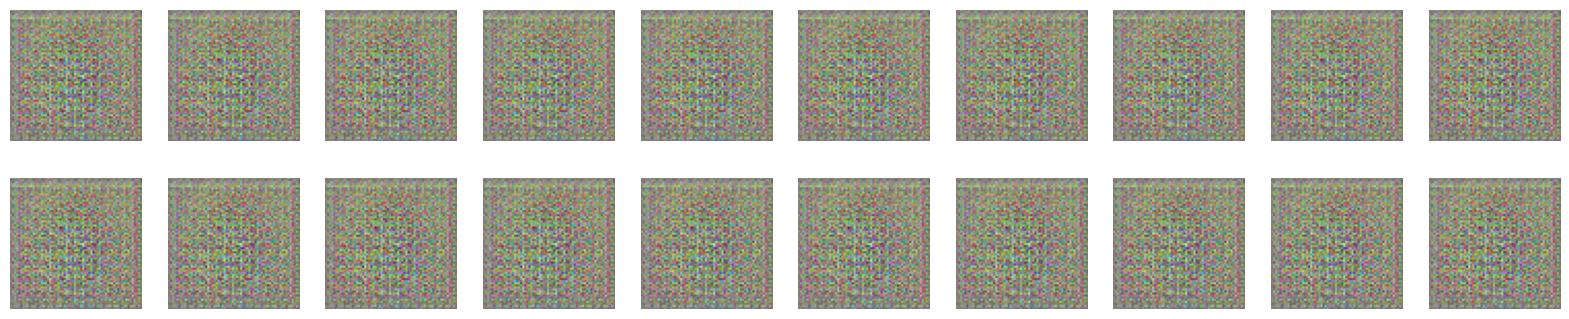

In [29]:
generate_sequences(generator, next_frame, current_frame)

## Training


In [30]:
log_dir=BASE_DIR / "logs/"
log_file = log_dir / "fit" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = tf.summary.create_file_writer(str(log_file))

In [31]:
@tf.function
def train_step(previous_frame, current_frame, next_frame, step):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    previous_gen_output = generator(previous_frame, training=True)
    current_gen_output = generator(current_frame, training=True)
    

    disc_real_output = discriminator([current_frame, next_frame], training=True)
    disc_generated_output = discriminator([current_frame, current_gen_output], training=True)
    
    gen_total_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss = generator_loss(
      disc_generated_output, previous_gen_output, current_gen_output, current_frame, next_frame
    )
    disc_loss = discriminator_loss(disc_real_output, disc_generated_output)
    generator_gradients = gen_tape.gradient(gen_total_loss,
                                            generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss,
                                                discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients,
                                            generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                discriminator.trainable_variables))
    with summary_writer.as_default():
      summary_step = step//1000
      tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=summary_step)
      tf.summary.scalar(f'gen_gan_loss', gen_gan_loss, step=summary_step)
      tf.summary.scalar(f'disc_loss', disc_loss, step=summary_step)
      if generator_loss.main_loss_function:
        tf.summary.scalar(f'gen_target_predicted', gen_target_predicted, step=summary_step)
      if generator_loss.coherence_loss_function:
        tf.summary.scalar(f'gen_coherence', gen_coherence_loss, step=summary_step)
      if generator_loss.landmarks_loss_function:
        tf.summary.scalar(f'gen_landmarks_loss', gen_landmarks_loss, step=summary_step)
      if generator_loss.landmarks_coherence_loss_function:
        tf.summary.scalar(f'gen_landmarks_coherence_loss', gen_landmarks_coherence_loss, step=summary_step)

In [32]:
def fit(train_dataset_generator, previous_frame_ex, current_frame_ex, next_frame_ex, steps):

  train_dataset = train_dataset_generator.take(steps)
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):
      previous_frame, current_frame, next_frame = next(train_dataset)

      if (step) % 5 == 0:
        clear_output(wait=True)
        display(pbar.container)
        generate_sequences(generator, current_frame_ex, next_frame_ex)
        tf.print("Working on input:")
        plot_normalized_sequence(current_frame)
        tf.print("Working on target:")
        plot_normalized_sequence(next_frame)

      train_step(previous_frame, current_frame, next_frame, step)

      # Save (checkpoint) the model every 5k steps
      if (step + 1) % 50 == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [33]:
previous_frame_ex, current_frame_ex, next_frame_ex = next(test_generator)

Restart datatset generator from begining

In [34]:
train_generator = FrameDataGenerator(train_paths, batch_size=BATCH_SIZE)

In [35]:
tf.profiler.experimental.start(str(log_dir))

2023-06-02 14:21:13.992342: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-06-02 14:21:13.992421: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.


  0%|          | 5/1000 [00:36<1:45:35,  6.37s/it]

Input Sequence


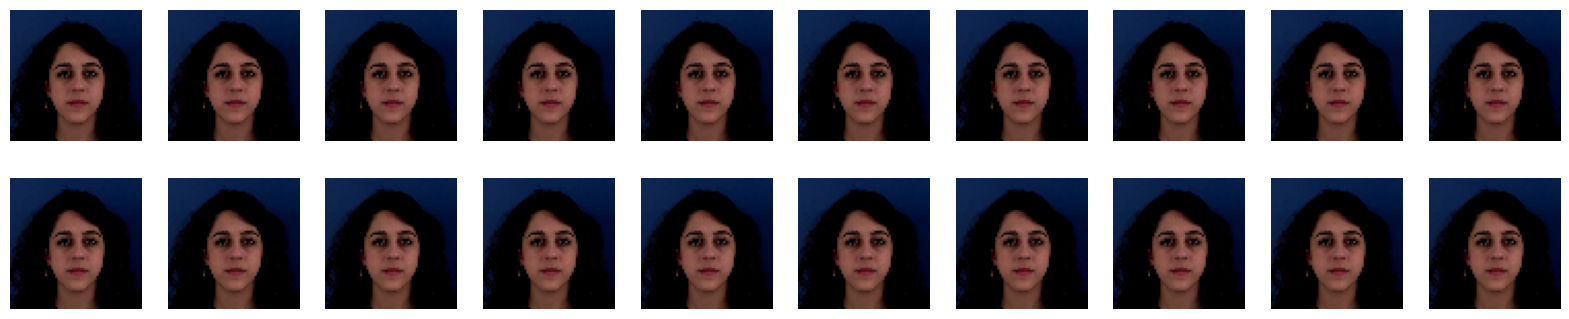

Ground Truth


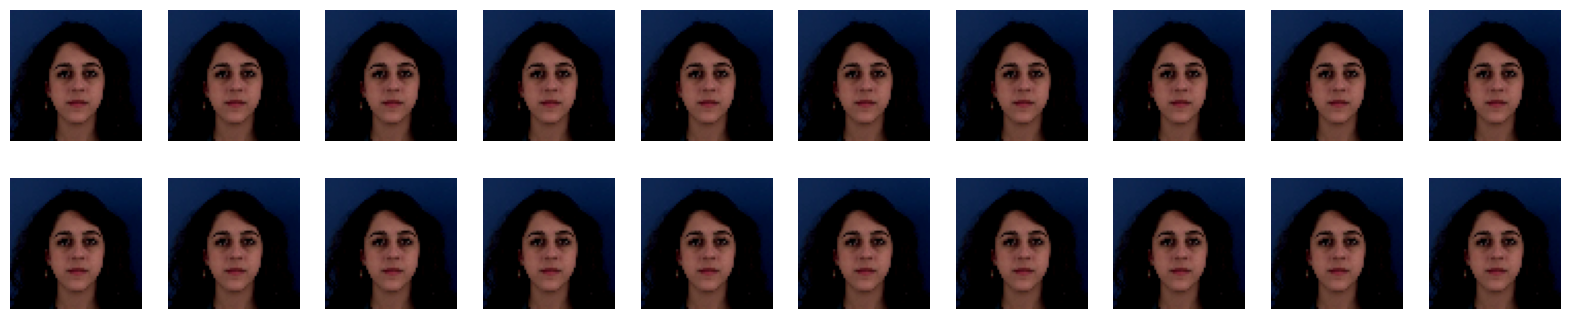

Predicted Sequence


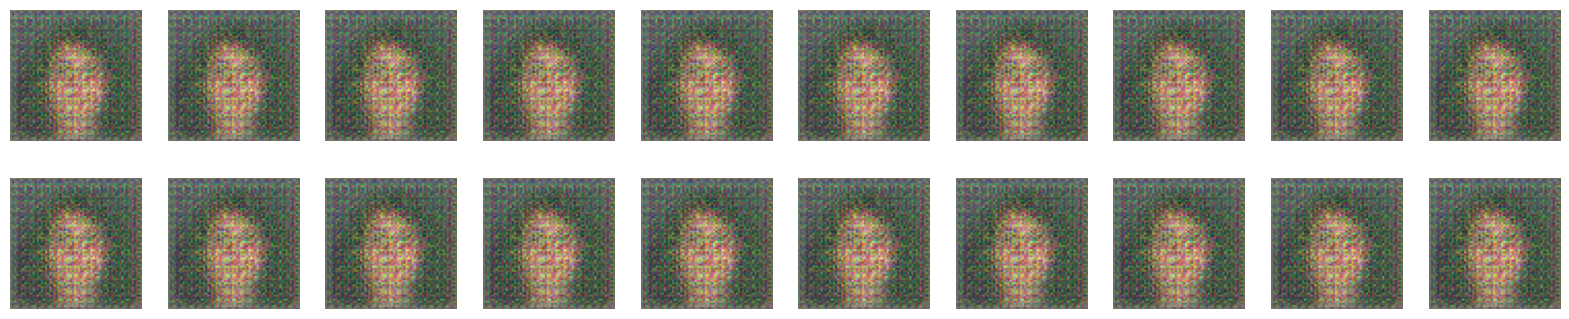

Working on input:


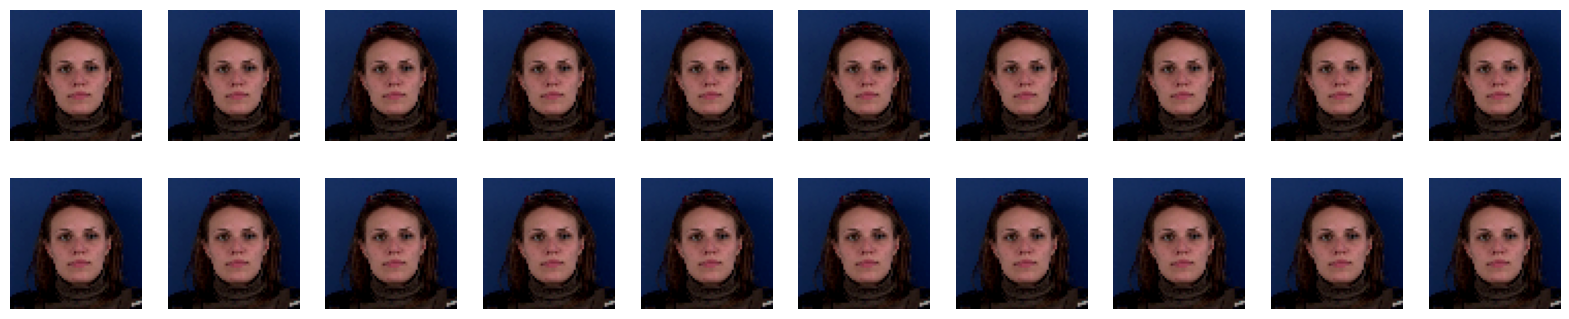

Working on target:


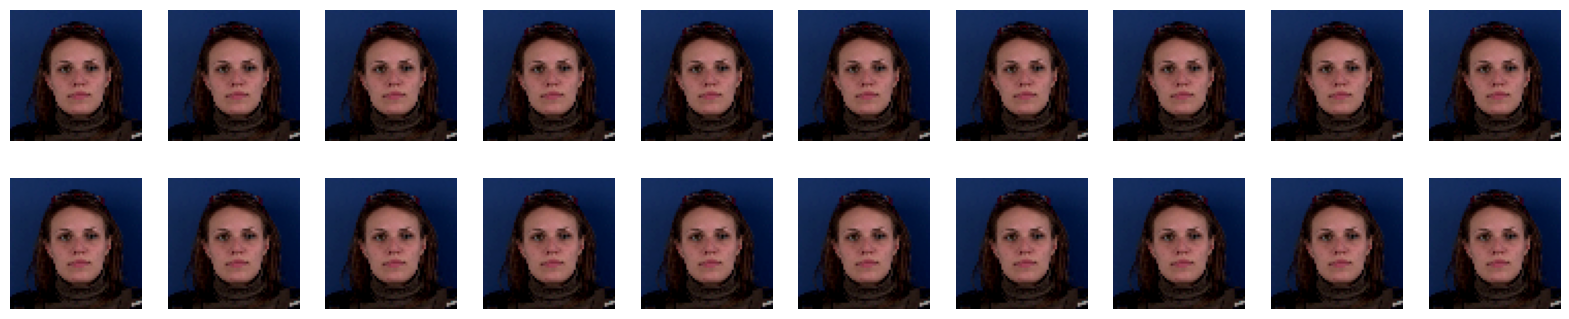

KeyboardInterrupt: 

In [36]:
fit(train_generator, previous_frame_ex, current_frame_ex, next_frame_ex, steps=STEPS)

## Restore the latest checkpoint and test the network

In [ ]:
!ls {checkpoint_dir}

In [ ]:
# Restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

In [ ]:
test_generator = FrameDataGenerator(test_paths, batch_size=BATCH_SIZE)

for i in range(0,10):
  previous_frame, current_frame, next_frame = next(test_generator)
  predicted_output = generator(current_frame, training=False)
  plot_results(current_frame, next_frame, predicted_output)

In [ ]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [ ]:
# evaluating the results with SSIM
def evaluate_metrics(target_sequence, generated_output, batch_size=BATCH_SIZE):
    unormalize_target_sequence = normalized_sequence_to_images(target_sequence)
    unormalize_generated_output = normalized_sequence_to_images(generated_output)
    #cast to float32
    target_sequence = tf.cast(target_sequence, tf.float32)
    generated_output = tf.cast(generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(unormalize_target_sequence, unormalize_generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(unormalize_target_sequence, unormalize_generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(target_sequence, generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(target_sequence, generated_output)
    # compute fid
    fid_scores = get_frechet_inception_distance(unormalize_target_sequence, unormalize_generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(unormalize_target_sequence, unormalize_generated_output)
    # compute acd
    acd_scores = compare_acd(unormalize_target_sequence, unormalize_generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }

test_generator = FrameDataGenerator(test_paths)
test_frames = np.array(list(test_generator))

scores = []
batch = 100
for i in tqdm(range(0, 1000, batch)):
  input_frames = test_frames[i:i+batch,1,:,:,:]
  target_frames = test_frames[i:i+batch,2,0,:,:]
  predicted_frames = np.array([generator(f, training=False) for f in input_frames])[:,0,...]
  score = evaluate_metrics(target_frames, predicted_frames, batch_size=batch)
  scores.append(score)

In [ ]:
len(scores)
df = pd.DataFrame(scores)
df.to_csv(f"{log_dir}/metrics1.csv")
print(df)

In [ ]:
print(df.mean())

In [ ]:
scores = {
    "SSIM": ssim_scores,
    "PSNR": psnr_scores,
    "MSE": mse_scores,
    "L1": l1_scores,
}

score_string = ""
for score_name in scores.keys():
    mean = tf.math.reduce_mean(scores[score_name])
    tf.print(f"{score_name} score: {mean}")
    score_string += f"{mean}\t"

tf.print(score_string)

In [ ]:
train_generator = FrameDataGenerator(train_paths)
train_frames = np.array(list(train_generator))
tf.print(train_frames.shape)

In [ ]:
test_generator = FrameDataGenerator(test_paths)
test_frames = np.array(list(test_generator))
tf.print(test_frames.shape)

## Different order

In [ ]:
new_order = [0, 10, 1, 11, 2, 12, 3, 13, 4, 14, 5, 15, 6, 16, 7, 17, 8, 18, 9]

# # Run the trained model on a few examples from the test set
# for i, (inp, tar) in enumerate(test_dataset.take(5)):
#   inp = tf.gather(inp, new_order, axis=-1)
#   tar = tf.gather(tar, new_order, axis=-1)
#   # inp = inp[..., new_order]
#   # tar = tar[..., new_order]
#   tf.print(i)
#   generate_sequences(generator, inp, tar, save_dir=save_dir)